<a href="https://colab.research.google.com/github/jashwanth-cse/bank-fraud-transaction-analysis/blob/main/notebook/Data_Science_SAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# ROUND II - EXPLORATORY DATA ANALYSIS
# Bank Fraud Transaction Analysis
# ============================================================

import pandas as pd
from scipy.stats import chi2_contingency

# -------------------- 1. LOAD DATA --------------------

from google.colab import drive
drive.mount('/content/drive')

# Change this path only if your file is in another folder
file_path = '/content/drive/MyDrive/Q10_bank_fraud.csv'

df = pd.read_csv(file_path)

print("========== DATASET INFORMATION ==========")
print("Rows and Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# -------------------- 2. CHECK DATA --------------------

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\nDuplicate records:", df.duplicated().sum())


# -------------------- 3. REMOVE DUPLICATES --------------------

df = df.drop_duplicates(subset='transaction_id').copy()


# -------------------- 4. FIX TIMESTAMP --------------------

df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    errors='coerce'
)

# Remove records with invalid timestamps
df = df.dropna(subset=['timestamp'])

# Remove records without transaction amount
df = df.dropna(subset=['transaction_amount_inr'])


# -------------------- 5. CREATE TIME-OF-DAY --------------------

def classify_time(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'


df['time_of_day'] = df['timestamp'].dt.hour.apply(classify_time)

# Keep the categories in logical order
time_order = ['Night', 'Morning', 'Afternoon', 'Evening']

df['time_of_day'] = pd.Categorical(
    df['time_of_day'],
    categories=time_order,
    ordered=True
)


# -------------------- 6. DESCRIPTIVE STATISTICS --------------------

print("\n========== TRANSACTION AMOUNT STATISTICS ==========")

print(
    df['transaction_amount_inr']
    .describe()
    .round(2)
)

print("\n========== AMOUNT BY FRAUD STATUS ==========")

print(
    df.groupby('fraud_status')['transaction_amount_inr']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)


# -------------------- 7. TIME-OF-DAY SUMMARY --------------------

print("\n========== TRANSACTIONS BY TIME OF DAY ==========")

print(
    df['time_of_day']
    .value_counts()
    .sort_index()
)


# -------------------- 8. CONTINGENCY TABLE --------------------

table = pd.crosstab(
    df['time_of_day'],
    df['fraud_status']
)

print("\n========== TIME OF DAY vs FRAUD STATUS ==========")
print(table)


# -------------------- 9. CHI-SQUARE TEST --------------------

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(table)

print("\n========== CHI-SQUARE TEST ==========")

print("Chi-Square Statistic :", round(chi2, 4))
print("Degrees of Freedom   :", degrees_of_freedom)
print("P-Value              :", round(p_value, 4))


# -------------------- 10. EXPECTED FREQUENCIES --------------------

expected_table = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print("\n========== EXPECTED FREQUENCIES ==========")
print(expected_table.round(2))


# -------------------- 11. FINAL DECISION --------------------

alpha = 0.05

print("\n========== FINAL DECISION ==========")

if p_value < alpha:
    print("Reject H0")
    print("There is a significant relationship between")
    print("time of day and fraud status.")
else:
    print("Fail to Reject H0")
    print("There is no significant relationship between")
    print("time of day and fraud status.")


# -------------------- 12. FRAUD RATE --------------------

fraud_rate = (
    df.groupby('time_of_day', observed=True)['fraud_status']
    .apply(lambda x: (x == 'Fraud').mean() * 100)
)

print("\n========== FRAUD RATE BY TIME OF DAY ==========")

print(fraud_rate.round(2))

print("\n========== CLEAN DATASET ==========")
print("Final number of records:", len(df))
# ------------------------------------------------------------
# 13. SAVE CLEANED DATASET
# ------------------------------------------------------------

cleaned_file = "Q10_bank_fraud_cleaned.csv"

df.to_csv(
    cleaned_file,
    index=False
)

print("\n========== CLEANED DATASET SAVED ==========")
print("File:", cleaned_file)
print("Rows:", len(df))
print("Columns:", len(df.columns))

from google.colab import files

files.download(cleaned_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
========== DATASET INFORMATION ==========
Rows and Columns: (123, 5)

Columns:
['transaction_id', 'timestamp', 'transaction_amount_inr', 'time_of_day', 'fraud_status']

========== DATA TYPES ==========
transaction_id             object
timestamp                  object
transaction_amount_inr    float64
time_of_day                object
fraud_status               object
dtype: object

========== MISSING VALUES ==========
transaction_id            0
timestamp                 1
transaction_amount_inr    2
time_of_day               1
fraud_status              0
dtype: int64

Duplicate records: 3

========== TRANSACTION AMOUNT STATISTICS ==========
count      118.00
mean     10145.79
std      12838.93
min        950.52
25%       3143.52
50%       6231.26
75%      12268.86
max      87857.28
Name: transaction_amount_inr, dtype: float64

========== AMOUNT BY FRAUD ST

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

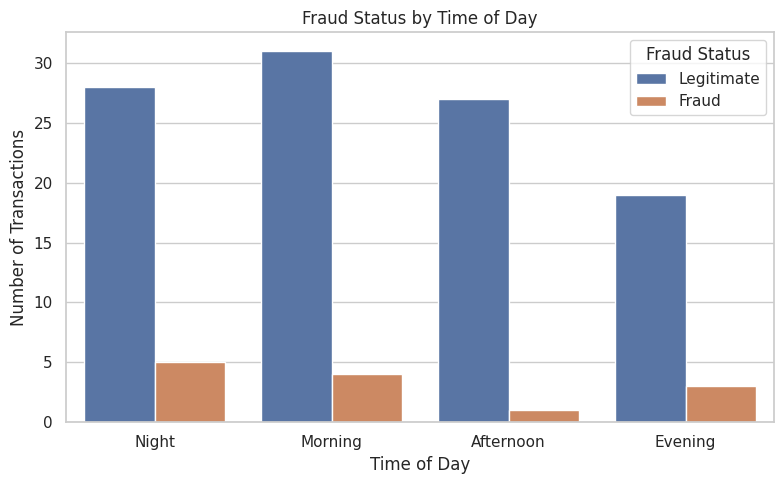

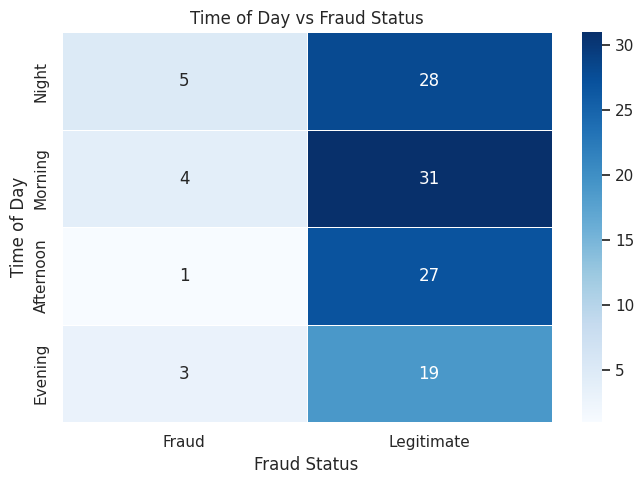

========== VISUALIZATION SUMMARY ==========

Bar Chart:
Shows the number of Fraud and Non-Fraud transactions
for each time-of-day category.

Heatmap:
Shows the concentration of Fraud and Non-Fraud
transactions across different time periods.

Chi-Square p-value: 0.5089

Conclusion:
Time of day does not have a statistically significant
relationship with fraud status.

Recommendation:
Use time of day as one fraud-monitoring feature,
but combine it with transaction amount, customer behavior,
location and transaction frequency for better detection.


In [3]:
# ============================================================
# ROUND III - DATA VISUALIZATION
# Bank Fraud Transaction Analysis
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean visualization style
sns.set_theme(style="whitegrid")


# ============================================================
# 1. BAR CHART
# Fraud Status by Time of Day
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='time_of_day',
    hue='fraud_status',
    order=['Night', 'Morning', 'Afternoon', 'Evening']
)

plt.title("Fraud Status by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Transactions")
plt.legend(title="Fraud Status")

plt.tight_layout()
plt.show()


# ============================================================
# 2. HEATMAP
# Time of Day vs Fraud Status
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title("Time of Day vs Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Time of Day")

plt.tight_layout()
plt.show()


# ============================================================
# 3. DISPLAY IMPORTANT RESULTS
# ============================================================

print("========== VISUALIZATION SUMMARY ==========")

print("\nBar Chart:")
print("Shows the number of Fraud and Non-Fraud transactions")
print("for each time-of-day category.")

print("\nHeatmap:")
print("Shows the concentration of Fraud and Non-Fraud")
print("transactions across different time periods.")

print("\nChi-Square p-value:", round(p_value, 4))

if p_value < 0.05:
    print("\nConclusion:")
    print("Time of day has a statistically significant relationship")
    print("with fraud status.")
else:
    print("\nConclusion:")
    print("Time of day does not have a statistically significant")
    print("relationship with fraud status.")

print("\nRecommendation:")
print("Use time of day as one fraud-monitoring feature,")
print("but combine it with transaction amount, customer behavior,")
print("location and transaction frequency for better detection.")